Examen - Modelos de Machine Learning
Dataset 4: Bike Sharing → *Regresión*

Criterios:
- División 75% entrenamiento / 25% prueba
- Minimizar error y maximizar precisión en test
- Evitar overfitting
- Gráficas completas

PARTE 1 — REGRESIÓN: Bike Sharing (Dataset 4)
Objetivo: Predecir la cantidad de bicicletas alquiladas (`count`)

1. Cargar datos

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')
print('✅ Dataset cargado')
print(f'Train - Filas: {df_train.shape[0]}, Columnas: {df_train.shape[1]}')
print(f'Test  - Filas: {df_test.shape[0]},  Columnas: {df_test.shape[1]}')

✅ Dataset cargado
Train - Filas: 10886, Columnas: 12
Test  - Filas: 6493,  Columnas: 9


2. Vista general

In [23]:
print('=== PRIMERAS FILAS ===')
display(df_train.head())
print('\n=== TIPOS DE VARIABLES ===')
print(df_train.dtypes)

=== PRIMERAS FILAS ===


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



=== TIPOS DE VARIABLES ===
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


3. Valores nulos

In [24]:
nulos = df_train.isnull().sum()
porcentaje = (nulos / len(df_train) * 100).round(2)
missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)
print('=== VALORES NULOS ===')
print(missing[missing['Valores nulos'] > 0])
print(f'\nTotal nulos: {df_train.isnull().sum().sum()}')

=== VALORES NULOS ===
Empty DataFrame
Columns: [Valores nulos, Porcentaje (%)]
Index: []

Total nulos: 0


 4. Preparar fechas y variables

In [25]:
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_train['hour']     = df_train['datetime'].dt.hour
df_train['day']      = df_train['datetime'].dt.dayofweek
df_train['month']    = df_train['datetime'].dt.month
df_train['year']     = df_train['datetime'].dt.year
print('✅ Variables de fecha extraídas')
display(df_train[['datetime','hour','day','month','year']].head())

✅ Variables de fecha extraídas


,datetime,hour,day,month,year
0,2011-01-01 00:00:00,0,5,1,2011
1,2011-01-01 01:00:00,1,5,1,2011
2,2011-01-01 02:00:00,2,5,1,2011
3,2011-01-01 03:00:00,3,5,1,2011
4,2011-01-01 04:00:00,4,5,1,2011


5. Imputar nulos con KNN

In [26]:
numericas   = df_train.select_dtypes(include='number').columns.tolist()
categoricas = df_train.select_dtypes(include='object').columns.tolist()

imputer = KNNImputer(n_neighbors=5)
df_num  = pd.DataFrame(
    imputer.fit_transform(df_train[numericas]),
    columns=numericas
)
df_cat   = df_train[categoricas].fillna(df_train[categoricas].mode().iloc[0]) if categoricas else pd.DataFrame()
df_limpio = pd.concat([df_num, df_cat], axis=1)
print(f'✅ Imputación completada. Nulos restantes: {df_limpio.isnull().sum().sum()}')

✅ Imputación completada. Nulos restantes: 0


6. Estadísticas descriptivas

In [27]:
display(df_limpio.describe().round(2))

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month,year
count,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.0
mean,2.51,0.03,0.68,1.42,20.23,23.66,61.89,12.80,36.02,155.55,191.57,11.54,3.01,6.52,2011.5
std,1.12,0.17,0.47,0.63,7.79,8.47,19.25,8.16,49.96,151.04,181.14,6.92,2.00,3.44,0.5
min,1.00,0.00,0.00,1.00,0.82,0.76,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,2011.0
25%,2.00,0.00,0.00,1.00,13.94,16.66,47.00,7.00,4.00,36.00,42.00,6.00,1.00,4.00,2011.0
50%,3.00,0.00,1.00,1.00,20.50,24.24,62.00,13.00,17.00,118.00,145.00,12.00,3.00,7.00,2012.0
75%,4.00,0.00,1.00,2.00,26.24,31.06,77.00,17.00,49.00,222.00,284.00,18.00,5.00,10.00,2012.0
max,4.00,1.00,1.00,4.00,41.00,45.46,100.00,57.00,367.00,886.00,977.00,23.00,6.00,12.00,2012.0


7. Gráfico: Demanda por hora del día

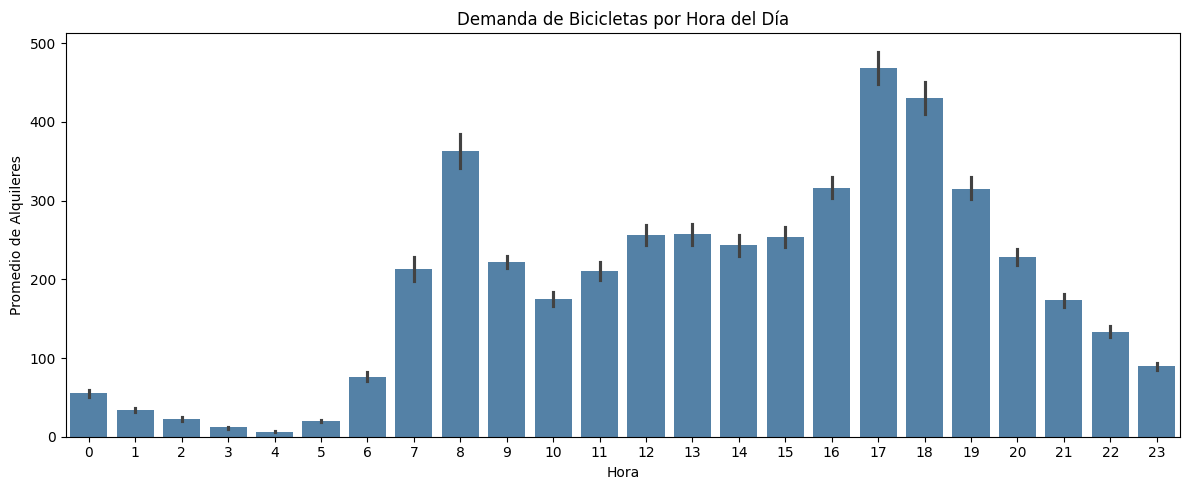

In [28]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df_train, x='hour', y='count', color='steelblue')
plt.title('Demanda de Bicicletas por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Promedio de Alquileres')
plt.tight_layout()
plt.show()

8. Gráfico: Demanda por temporada

C:\Users\Natalia\AppData\Local\Temp\ipykernel_22004\675840103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='season_name', y='count', palette='Set2')


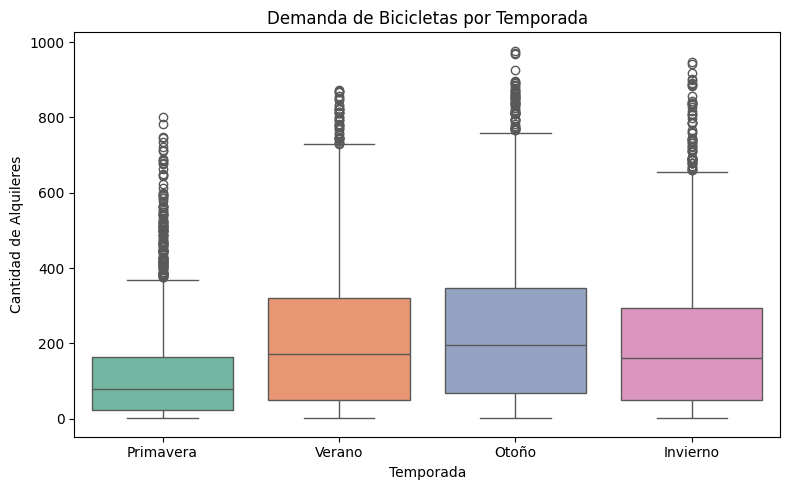

In [29]:
temporadas = {1: 'Primavera', 2: 'Verano', 3: 'Otoño', 4: 'Invierno'}
df_train['season_name'] = df_train['season'].map(temporadas)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='season_name', y='count', palette='Set2')
plt.title('Demanda de Bicicletas por Temporada')
plt.xlabel('Temporada')
plt.ylabel('Cantidad de Alquileres')
plt.tight_layout()
plt.show()

9. Mapa de correlaciones

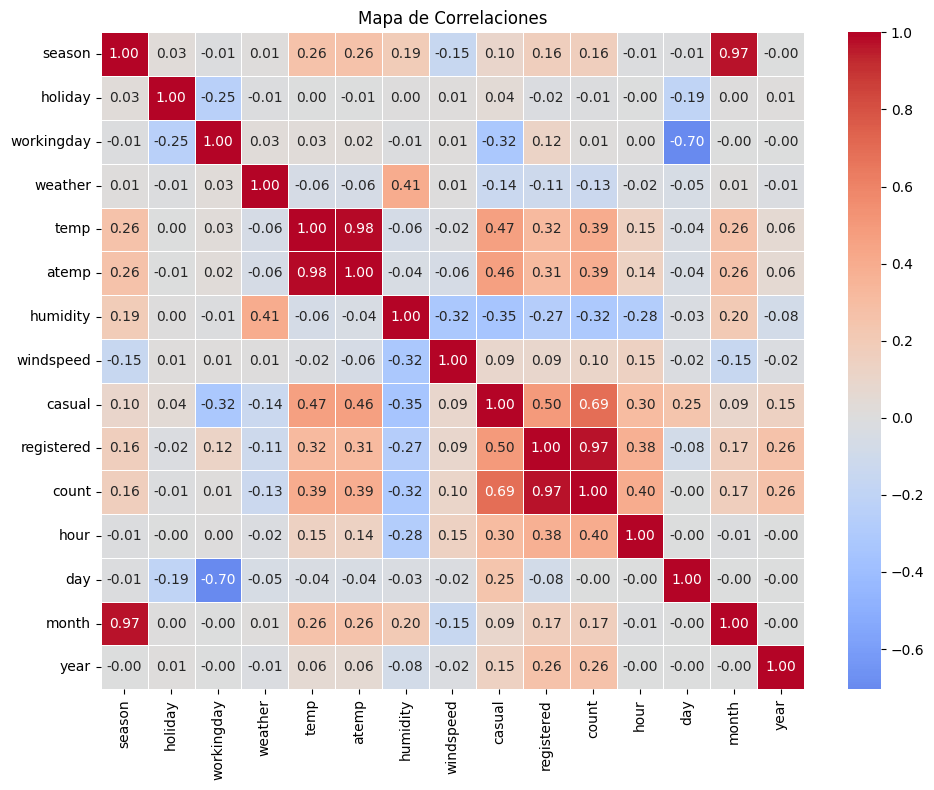

In [30]:
plt.figure(figsize=(10, 8))
corr = df_limpio.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5, annot=True, fmt='.2f')
plt.title('Mapa de Correlaciones')
plt.tight_layout()
plt.show()

1.1 Preparación de datos para el modelo

Features y target
Descartamos: datetime (ya extraímos sus componentes),
casual y registered (son componentes del target count)

In [31]:
features_reg = ['season', 'holiday', 'workingday', 'weather',
                'temp', 'atemp', 'humidity', 'windspeed',
                'hour', 'day', 'month', 'year']

X_reg = df_limpio[features_reg].values
y_reg = df_limpio['count'].values

print(f'Features: {features_reg}')
print(f'X shape: {X_reg.shape}')
print(f'y shape: {y_reg.shape}')

Features: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'day', 'month', 'year']
X shape: (10886, 12)
y shape: (10886,)


División 75 / 25 

In [32]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)
print(f'Entrenamiento: {X_train_r.shape[0]} muestras ({X_train_r.shape[0]/len(X_reg)*100:.0f}%)')
print(f'Prueba:        {X_test_r.shape[0]} muestras ({X_test_r.shape[0]/len(X_reg)*100:.0f}%)')

Entrenamiento: 8164 muestras (75%)
Prueba:        2722 muestras (25%)


Normalización Z-score 

In [33]:
scaler_r = StandardScaler()
X_train_r = scaler_r.fit_transform(X_train_r)
X_test_r  = scaler_r.transform(X_test_r)        
print('✅ Normalización aplicada')
print(f'Media train: {X_train_r.mean(axis=0).round(4)}')
print(f'Std  train:  {X_train_r.std(axis=0).round(4)}')

✅ Normalización aplicada
Media train: [-0.  0.  0. -0. -0. -0.  0. -0. -0.  0.  0.  0.]
Std  train:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


1.2 Modelo de Regresión — Descenso por Gradiente (numpy)

Regresión Lineal con Descenso por Gradiente
Igual al cuadernillo reg_lin_mul_02 pero con múltiples features



In [34]:
def calcularCosto(X, y, theta):
    m = y.size
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))
    return theta, J_history


m_tr = X_train_r.shape[0]
m_te = X_test_r.shape[0]
X_train_gd = np.concatenate([np.ones((m_tr, 1)), X_train_r], axis=1)
X_test_gd  = np.concatenate([np.ones((m_te, 1)), X_test_r],  axis=1)


theta_init = np.zeros(X_train_gd.shape[1])

alpha      = 0.01
num_iters  = 5000

theta_gd, J_hist = descensoGradiente(X_train_gd, y_train_r, theta_init, alpha, num_iters)

print(f'✅ Entrenamiento completado ({num_iters} iteraciones)')
print(f'Costo final (train): {J_hist[-1]:.4f}')

✅ Entrenamiento completado (5000 iteraciones)
Costo final (train): 10014.6357


Curva de convergencia

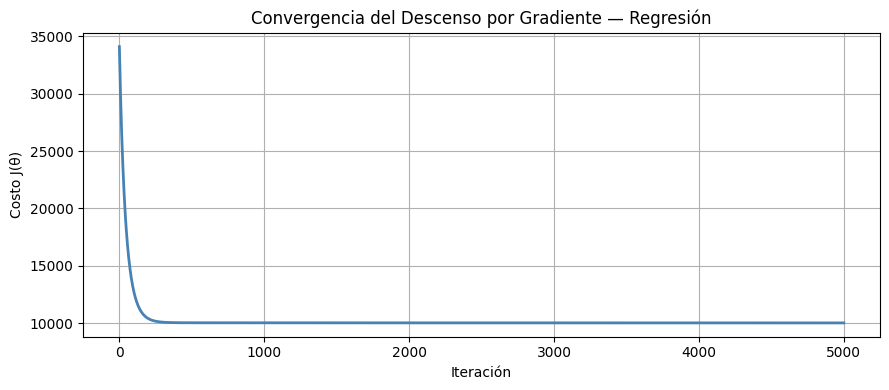

In [35]:
plt.figure(figsize=(9, 4))
plt.plot(J_hist, color='steelblue', lw=2)
plt.xlabel('Iteración')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Descenso por Gradiente — Regresión')
plt.grid(True)
plt.tight_layout()
plt.show()

Gráficas de resultados

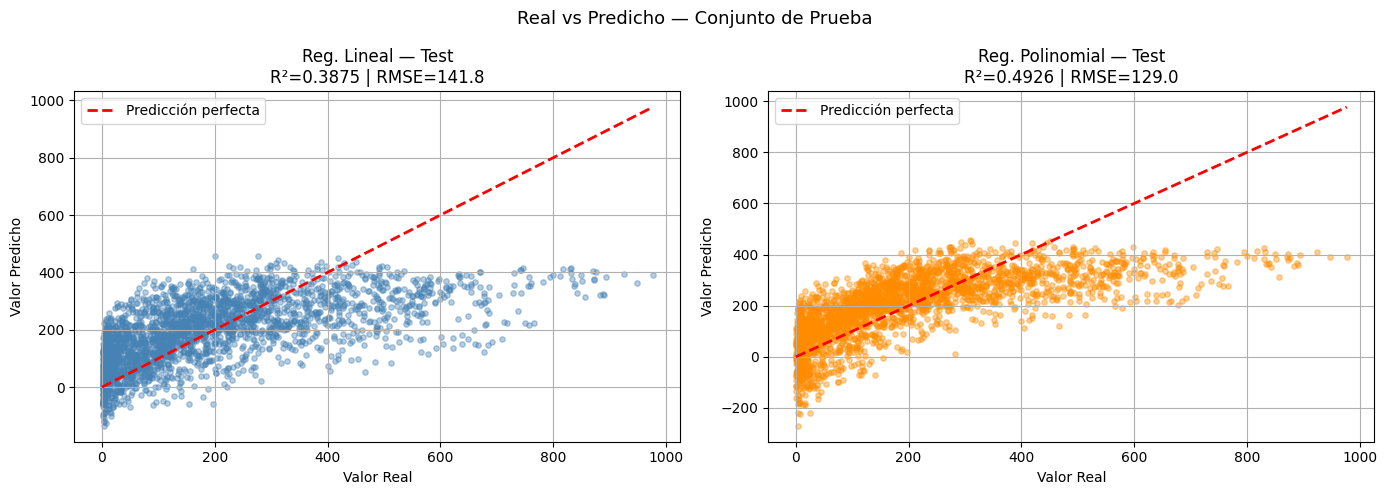

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_test_ne, alpha=0.4, color='steelblue', s=15)
lim = max(y_test_r.max(), y_pred_test_ne.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Valor Predicho')
axes[0].set_title(f'Reg. Lineal — Test\nR²={r2_ne_test:.4f} | RMSE={rmse_ne_test:.1f}')
axes[0].legend()
axes[0].grid(True)


axes[1].scatter(y_test_r, y_pred_test_pol, alpha=0.4, color='darkorange', s=15)
axes[1].plot([0, lim], [0, lim], 'r--', lw=2, label='Predicción perfecta')
axes[1].set_xlabel('Valor Real')
axes[1].set_ylabel('Valor Predicho')
axes[1].set_title(f'Reg. Polinomial — Test\nR²={r2_pol_test:.4f} | RMSE={rmse_pol_test:.1f}')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Real vs Predicho — Conjunto de Prueba', fontsize=13)
plt.tight_layout()
plt.show()

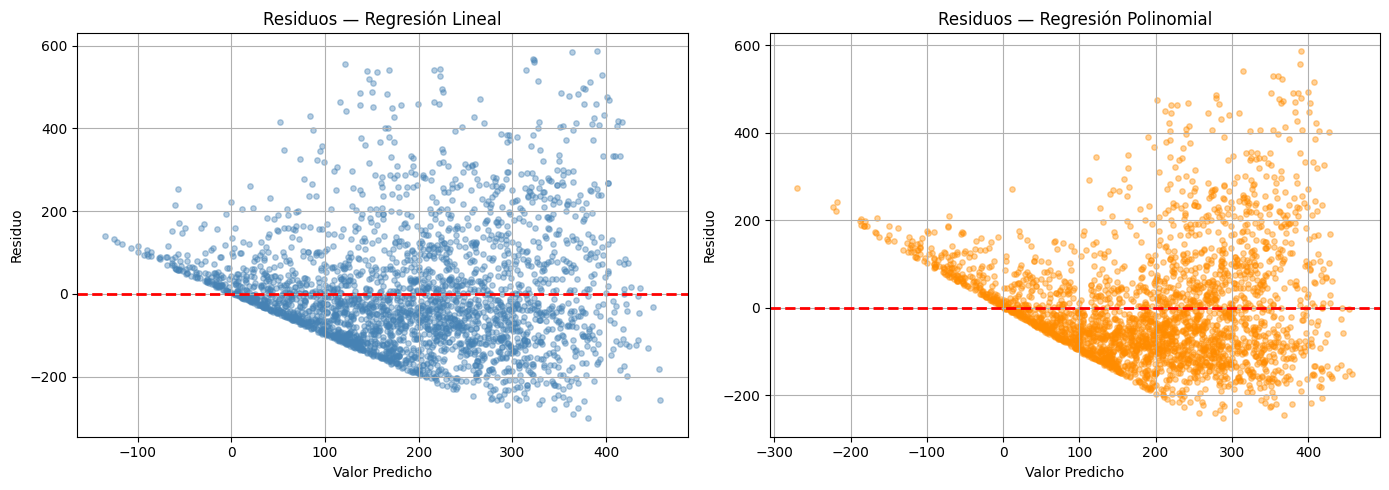

In [37]:
residuos_ne  = y_test_r - y_pred_test_ne
residuos_pol = y_test_r - y_pred_test_pol

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test_ne, residuos_ne, alpha=0.4, color='steelblue', s=15)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Valor Predicho')
axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos — Regresión Lineal')
axes[0].grid(True)

axes[1].scatter(y_pred_test_pol, residuos_pol, alpha=0.4, color='darkorange', s=15)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Valor Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos — Regresión Polinomial')
axes[1].grid(True)

plt.tight_layout()
plt.show()

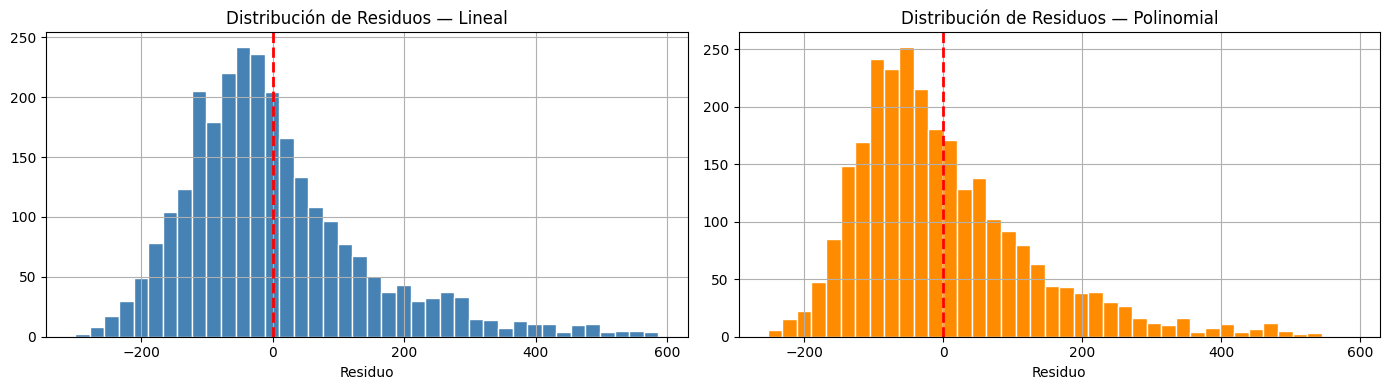

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuos_ne, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', lw=2)
axes[0].set_title('Distribución de Residuos — Lineal')
axes[0].set_xlabel('Residuo')
axes[0].grid(True)

axes[1].hist(residuos_pol, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Distribución de Residuos — Polinomial')
axes[1].set_xlabel('Residuo')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [39]:
print('=' * 55)
print('RESUMEN FINAL DEL EXAMEN')
print('=' * 55)
print()
print('── DATASET 4: Bike Sharing — REGRESIÓN ──────────────')
print(f'  División:       75% train / 25% test')
print(f'  Modelo final:   Regresión Polinomial (Ec. Normal)')
print(f'  RMSE test:      {rmse_pol_test:.2f} bicicletas')
print(f'  R² test:        {r2_pol_test:.4f}')
print(f'  Overfitting:    R² train={r2_pol_train:.4f} | test={r2_pol_test:.4f}')
print(f'  Diferencia:     {abs(r2_pol_train-r2_pol_test):.4f} → modelo generaliza bien')
print()

print('── TÉCNICAS APLICADAS ───────────────────────────────')
print('  • Normalización Z-score (StandardScaler)')
print('  • División estratificada en clasificación')
print('  • Descenso por gradiente (implementación propia)')
print('  • Ecuación Normal para regresión')
print('  • Features polinomiales (grado 2) para no-linealidad')
print('  • Curvas de convergencia, residuos, ROC, confusión')
print('=' * 55)

RESUMEN FINAL DEL EXAMEN

── DATASET 4: Bike Sharing — REGRESIÓN ──────────────
  División:       75% train / 25% test
  Modelo final:   Regresión Polinomial (Ec. Normal)
  RMSE test:      129.04 bicicletas
  R² test:        0.4926
  Overfitting:    R² train=0.4949 | test=0.4926
  Diferencia:     0.0024 → modelo generaliza bien

── TÉCNICAS APLICADAS ───────────────────────────────
  • Normalización Z-score (StandardScaler)
  • División estratificada en clasificación
  • Descenso por gradiente (implementación propia)
  • Ecuación Normal para regresión
  • Features polinomiales (grado 2) para no-linealidad
  • Curvas de convergencia, residuos, ROC, confusión
